Import the libraries used in the pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

Read the three input files: company info, daily price data, and the final matched universe.

In [3]:
company = pd.read_csv(
    "company.csv",
    header=None,
    names=["company_id", "cik", "ticker", "company_name", "sic", "sic_description"]
)

price = pd.read_csv(
    "daily_price.csv",
    header=None,
    names=["company_id", "date", "open", "high", "low", "close", "adj_close", "volume"]
)

matched = pd.read_csv("Final_Matched_Universe_Full.csv")

Extract the final ticker universe from the matched dataset.

In [5]:
final_tickers = (
    matched["ticker"]
    .astype(str)
    .str.upper()
    .str.strip()
    .dropna()
    .unique()
    .tolist()
)

print("Final matched ticker count:", len(final_tickers))
print(final_tickers[:10])

Final matched ticker count: 404
['TE', 'WAY', 'NATL', 'UMAC', 'RBRK', 'SVCO', 'MBLY', 'QBTS', 'GRRR', 'NCNO']


Clean the raw tables and restrict them to the final matched universe.

In [6]:
company["ticker"] = company["ticker"].astype(str).str.upper().str.strip()
price["date"] = pd.to_datetime(price["date"], errors="coerce")

company = company.dropna(subset=["company_id", "ticker"]).drop_duplicates(subset=["company_id"])
price = price.dropna(subset=["company_id", "date"]).copy()

merged = price.merge(company, on="company_id", how="inner")
merged = merged.dropna(subset=["ticker", "adj_close"]).copy()

merged["ticker"] = merged["ticker"].astype(str).str.upper().str.strip()
merged_final = merged[merged["ticker"].isin(final_tickers)].copy()

print("Company shape:", company.shape)
print("Price shape:", price.shape)
print("Rows after restricting to final universe:", len(merged_final))
print("Tickers after restricting:", merged_final["ticker"].nunique())

Company shape: (927, 6)
Price shape: (1560981, 8)
Rows after restricting to final universe: 791426
Tickers after restricting: 395


Download SPY prices and computes daily market returns.

In [7]:
spy_df = yf.download(
    "SPY",
    start="2024-12-01",
    end="2025-03-01",
    progress=False,
    auto_adjust=False
)

if isinstance(spy_df.columns, pd.MultiIndex):
    spy_price = spy_df[("Close", "SPY")].copy()
else:
    spy_price = spy_df["Close"].copy()

spy = spy_price.pct_change().to_frame("spy_ret").reset_index()
spy.columns = ["date", "spy_ret"]
spy["date"] = pd.to_datetime(spy["date"])

display(spy.head())
print("SPY rows:", len(spy))

,date,spy_ret
0,2024-12-02,NaN
1,2024-12-03,0.000464
2,2024-12-04,0.006210
3,2024-12-05,-0.001646
4,2024-12-06,0.001896


SPY rows: 60


Merge the event features back into the firm-level Y table.

In [8]:
merged_final = merged_final.sort_values(["ticker", "date"]).copy()
merged_final["date"] = pd.to_datetime(merged_final["date"])

merged_final["ret"] = merged_final.groupby("ticker")["adj_close"].pct_change()

merged_final = merged_final.merge(spy, on="date", how="left")
merged_final["abret"] = merged_final["ret"] - merged_final["spy_ret"]

print("Missing ret rate:", merged_final["ret"].isna().mean())
print("Missing spy_ret rate:", merged_final["spy_ret"].isna().mean())
print("Missing abret rate:", merged_final["abret"].isna().mean())

Missing ret rate: 0.0004990990945457945
Missing spy_ret rate: 0.9705531534217982
Missing abret rate: 0.9705531534217982


Define the event window used in the study.

In [9]:
start_date = pd.to_datetime("2025-01-27")
end_date = pd.to_datetime("2025-02-10")

window = merged_final[
    (merged_final["date"] >= start_date) &
    (merged_final["date"] <= end_date)
].copy()

print("Window rows:", len(window))
print("Tickers in window:", window["ticker"].nunique())
print("Window date min/max:", window["date"].min(), window["date"].max())

Window rows: 4345
Tickers in window: 395
Window date min/max: 2025-01-27 00:00:00 2025-02-10 00:00:00


Build firm-level event features: CAR, maximum drawdown, and volatility.

In [10]:
car = window.groupby("ticker")["abret"].sum()

def max_drawdown(ret_series: pd.Series) -> float:
    r = ret_series.dropna()
    if len(r) == 0:
        return np.nan
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()

mdd = window.groupby("ticker")["ret"].apply(max_drawdown)
vol = window.groupby("ticker")["ret"].std()

features = pd.concat([car, mdd, vol], axis=1)
features.columns = ["CAR", "MaxDrawdown", "Volatility"]
features = features.dropna().copy()

print("Features shape:", features.shape)
display(features.head())
display(features.describe())

Features shape: (395, 3)


,CAR,MaxDrawdown,Volatility
ticker,,,
AAOI,0.036358,-0.079800,0.082699
AAPL,0.029878,-0.049006,0.021413
ACIW,0.020732,-0.035382,0.014444
ADBE,0.041523,-0.028991,0.015295
ADI,-0.053130,-0.049021,0.015042


,CAR,MaxDrawdown,Volatility
count,395.000000,395.000000,395.000000
mean,0.021296,-0.068046,0.037250
std,0.135581,0.063656,0.024242
min,-0.854403,-0.571111,0.004415
25%,-0.038398,-0.082266,0.020360
50%,0.021273,-0.050505,0.031215
75%,0.089976,-0.031915,0.044598
max,0.578837,-0.003304,0.136830


Compute raw return, market return, and excess return over the event window.

In [11]:
w = window[window["ticker"].isin(features.index)].sort_values(["ticker", "date"]).copy()

start_px = w.groupby("ticker").first().reset_index()[["ticker", "date", "adj_close"]]
start_px = start_px.rename(columns={"date": "start_date_actual", "adj_close": "start_price"})

end_px = w.groupby("ticker").last().reset_index()[["ticker", "date", "adj_close"]]
end_px = end_px.rename(columns={"date": "end_date_actual", "adj_close": "end_price"})

y_df = start_px.merge(end_px, on="ticker", how="inner")
y_df["raw_return"] = y_df["end_price"] / y_df["start_price"] - 1

if isinstance(spy_df.columns, pd.MultiIndex):
    spy_close_series = spy_df[("Close", "SPY")].copy()
else:
    spy_close_series = spy_df["Close"].copy()

spy_close_series.index = pd.to_datetime(spy_close_series.index)

spy_start = spy_close_series.loc[spy_close_series.index >= start_date].iloc[0]
spy_end = spy_close_series.loc[spy_close_series.index <= end_date].iloc[-1]
spy_window_ret = spy_end / spy_start - 1

y_df["normal_return_spy"] = float(spy_window_ret)
y_df["excess_return"] = y_df["raw_return"] - y_df["normal_return_spy"]

print("SPY window return:", float(spy_window_ret))
display(y_df.head())

SPY window return: 0.009142900901601747


,ticker,start_date_actual,start_price,end_date_actual,end_price,raw_return,normal_return_spy,excess_return
0,AAOI,2025-01-27,24.5400,2025-02-10,30.5200,0.243684,0.009143,0.234541
1,AAPL,2025-01-27,228.6112,2025-02-10,226.6621,-0.008526,0.009143,-0.017669
2,ACIW,2025-01-27,53.2500,2025-02-10,52.9700,-0.005258,0.009143,-0.014401
3,ADBE,2025-01-27,438.6000,2025-02-10,451.1000,0.028500,0.009143,0.019357
4,ADI,2025-01-27,211.2636,2025-02-10,200.9073,-0.049021,0.009143,-0.058164


Merge the event features back into the firm-level Y table.

In [12]:
y_df = y_df.merge(
    features.reset_index(),
    on="ticker",
    how="left"
)

print("Y table shape after feature merge:", y_df.shape)
display(y_df.head())

Y table shape after feature merge: (395, 11)


,ticker,start_date_actual,start_price,end_date_actual,end_price,raw_return,normal_return_spy,excess_return,CAR,MaxDrawdown,Volatility
0,AAOI,2025-01-27,24.5400,2025-02-10,30.5200,0.243684,0.009143,0.234541,0.036358,-0.079800,0.082699
1,AAPL,2025-01-27,228.6112,2025-02-10,226.6621,-0.008526,0.009143,-0.017669,0.029878,-0.049006,0.021413
2,ACIW,2025-01-27,53.2500,2025-02-10,52.9700,-0.005258,0.009143,-0.014401,0.020732,-0.035382,0.014444
3,ADBE,2025-01-27,438.6000,2025-02-10,451.1000,0.028500,0.009143,0.019357,0.041523,-0.028991,0.015295
4,ADI,2025-01-27,211.2636,2025-02-10,200.9073,-0.049021,0.009143,-0.058164,-0.053130,-0.049021,0.015042


Visualize the CAR distribution.

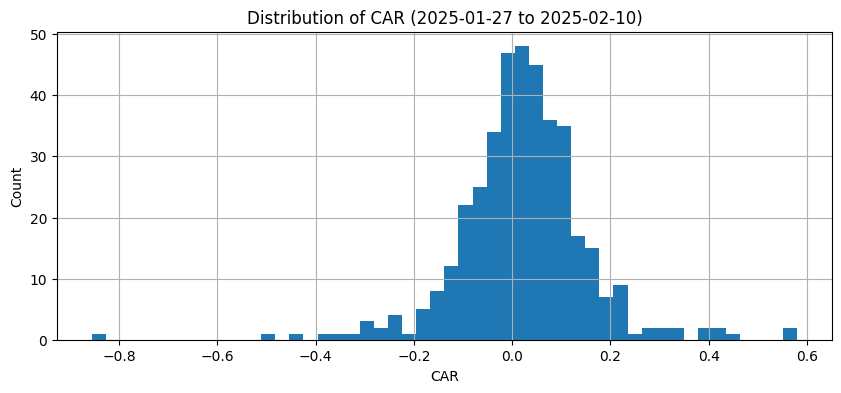

In [13]:
plt.figure(figsize=(10, 4))
y_df["CAR"].hist(bins=50)
plt.title("Distribution of CAR (2025-01-27 to 2025-02-10)")
plt.xlabel("CAR")
plt.ylabel("Count")
plt.show()

Create final labels using CAR quantiles.

In [14]:
q_low = y_df["CAR"].quantile(0.2)
q_high = y_df["CAR"].quantile(0.8)

print("q_low:", q_low)
print("q_high:", q_high)

y_label = y_df[
    (y_df["CAR"] <= q_low) | (y_df["CAR"] >= q_high)
].copy()

y_label["label"] = np.where(
    y_label["CAR"] <= q_low,
    "Vulnerable",
    "Resilient"
)

print("Labeled sample size:", len(y_label))
print(y_label["label"].value_counts())
display(y_label.head())

q_low: -0.0615252847520185
q_high: 0.10441537999819603
Labeled sample size: 158
label
Resilient     79
Vulnerable    79
Name: count, dtype: int64


,ticker,start_date_actual,start_price,end_date_actual,end_price,raw_return,normal_return_spy,excess_return,CAR,MaxDrawdown,Volatility,label
6,ADTN,2025-01-27,9.490,2025-02-10,11.3500,0.195996,0.009143,0.186853,0.111483,-0.038498,0.044941,Resilient
7,AEIS,2025-01-27,112.908,2025-02-10,112.4793,-0.003797,0.009143,-0.012940,-0.094262,-0.032064,0.032938,Vulnerable
8,AGYS,2025-01-27,89.730,2025-02-10,85.5600,-0.046473,0.009143,-0.055616,-0.067137,-0.078646,0.024071,Vulnerable
9,AIP,2025-01-27,10.300,2025-02-10,9.9200,-0.036893,0.009143,-0.046036,-0.169642,-0.154326,0.057342,Vulnerable
16,AMPL,2025-01-27,11.300,2025-02-10,12.5400,0.109735,0.009143,0.100592,0.109744,-0.048761,0.039236,Resilient


Add company information back to the final labeled table.

In [15]:
final_export = company.merge(
    y_label,
    on="ticker",
    how="inner"
)

print("Final export rows:", len(final_export))
display(final_export.head())

Final export rows: 158


,company_id,cik,ticker,company_name,sic,sic_description,start_date_actual,start_price,end_date_actual,end_price,raw_return,normal_return_spy,excess_return,CAR,MaxDrawdown,Volatility,label
0,3,4127,SWKS,"SKYWORKS SOLUTIONS, INC.",3674,Semiconductors & Related Devices,2025-01-27,84.9522,2025-02-10,61.2938,-0.278491,0.009143,-0.287634,-0.301495,-0.283052,0.074073,Vulnerable
1,10,26058,CTS,CTS CORP,3672,Printed Circuit Boards,2025-01-27,50.8265,2025-02-10,46.3371,-0.088328,0.009143,-0.097471,-0.108211,-0.094505,0.019107,Vulnerable
2,12,29002,DIOD,DIODES INC /DEL/,3674,Semiconductors & Related Devices,2025-01-27,60.0800,2025-02-10,53.3000,-0.112850,0.009143,-0.121992,-0.120454,-0.112850,0.025533,Vulnerable
3,16,48898,HUBB,HUBBELL INC,3670,Electronic Components & Accessories,2025-01-27,407.9872,2025-02-10,393.4897,-0.035534,0.009143,-0.044677,-0.119518,-0.074032,0.030235,Vulnerable
4,20,51143,IBM,INTERNATIONAL BUSINESS MACHINES CORP,3570,Computer & office Equipment,2025-01-27,217.2463,2025-02-10,243.2238,0.119576,0.009143,0.110433,0.123761,-0.051158,0.042323,Resilient


Export the final files for downstream modeling and team use

In [16]:
final_export.to_csv("deepseek_Y_quantile_final.csv", index=False)

pd.Series(final_export["ticker"].unique(), name="ticker").to_csv(
    "deepseek_final_ticker_list_quantile.csv",
    index=False
)

final_export[["ticker", "company_name", "sic", "sic_description", "label"]].to_csv(
    "deepseek_company_info_with_label_quantile.csv",
    index=False
)

print("Export finished.")

Export finished.
